# ERA-5 2-meter temperature Visualization

```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

---

## Overview

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Xarray](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Necessary | |
- **Time to learn**: 20 minutes.

---

## Imports

In [2]:
import fsspec
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scipy.spatial
import numpy as np
import cf_xarray as cfxr
from metpy.units import units

## Access the ARCO ERA-5 catalog on Google Cloud

Test bucket access with fsspec

In [3]:
fs = fsspec.filesystem('gs')
fs.ls('gs://gcp-public-data-arco-era5/co')

['gcp-public-data-arco-era5/co/model-level-moisture.zarr',
 'gcp-public-data-arco-era5/co/model-level-moisture.zarr-v2',
 'gcp-public-data-arco-era5/co/model-level-wind.zarr',
 'gcp-public-data-arco-era5/co/model-level-wind.zarr-v2',
 'gcp-public-data-arco-era5/co/single-level-forecast.zarr',
 'gcp-public-data-arco-era5/co/single-level-forecast.zarr-v2',
 'gcp-public-data-arco-era5/co/single-level-reanalysis.zarr',
 'gcp-public-data-arco-era5/co/single-level-reanalysis.zarr-v2',
 'gcp-public-data-arco-era5/co/single-level-surface.zarr',
 'gcp-public-data-arco-era5/co/single-level-surface.zarr-v2']

open the single-level-reanalysis Zarr file.

In [4]:
reanalysis = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/co/single-level-reanalysis.zarr', 
    chunks={'time': 48},
    consolidated=True,
)

/tmp/ipykernel_4062358/165558829.py:1: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  reanalysis = xr.open_zarr(


In [5]:
print(f'size: {reanalysis.nbytes / (1024 ** 4)} TB')

size: 28.02835009436967 TB


In [6]:
reanalysis

<xarray.Dataset> Size: 31TB
Dimensions:              (time: 374016, values: 542080)
Coordinates:
  * time                 (time) datetime64[ns] 3MB 1979-01-01 ... 2021-08-31T...
    depthBelowLandLayer  float64 8B ...
    entireAtmosphere     float64 8B ...
    latitude             (values) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    longitude            (values) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    number               int64 8B ...
    step                 timedelta64[ns] 8B ...
    surface              float64 8B ...
    valid_time           (time) datetime64[ns] 3MB dask.array<chunksize=(48,), meta=np.ndarray>
Dimensions without coordinates: values
Data variables: (12/38)
    cape                 (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    d2m                  (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    hcc                  (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    istl1                (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    istl2                (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    istl3                (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    ...                   ...
    tsn                  (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    u10                  (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    u100                 (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    v10                  (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    v100                 (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
    z                    (time, values) float32 811GB dask.array<chunksize=(48, 542080), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.7
    GRIB_centre:               ecmf
    GRIB_centreDescription:    European Centre for Medium-Range Weather Forec...
    GRIB_edition:              1
    GRIB_subCentre:            0
    history:                   2022-09-23T18:56 GRIB to CDM+CF via cfgrib-0.9...
    institution:               European Centre for Medium-Range Weather Forec...
    pangeo-forge:inputs_hash:  5f4378143e9f42402424280b63472752da3aa79179b53b...
    pangeo-forge:recipe_hash:  0c3415923e347ce9dac9dc5c6d209525f4d45d799bd25b...
    pangeo-forge:version:      0.9.1

Let’s look at the 2 metre temperature variable.

In [7]:
tem = reanalysis.t2m
tem

<xarray.DataArray 't2m' (time: 374016, values: 542080)> Size: 811GB
dask.array<open_dataset-t2m, shape=(374016, 542080), dtype=float32, chunksize=(48, 542080), chunktype=numpy.ndarray>
Coordinates:
  * time                 (time) datetime64[ns] 3MB 1979-01-01 ... 2021-08-31T...
    depthBelowLandLayer  float64 8B ...
    entireAtmosphere     float64 8B ...
    latitude             (values) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    longitude            (values) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    number               int64 8B ...
    step                 timedelta64[ns] 8B ...
    surface              float64 8B ...
    valid_time           (time) datetime64[ns] 3MB dask.array<chunksize=(48,), meta=np.ndarray>
Dimensions without coordinates: values
Attributes: (12/25)
    GRIB_N:                                   320
    GRIB_NV:                                  0
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    GRIB_gridDefinitionDescription:           Gaussian Latitude/Longitude Grid
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

convert to degC

In [8]:
if tem.attrs.get('units') == 'K':
    tem = tem - 273.15
    tem.attrs['units'] = 'degC'

In [9]:
tem

<xarray.DataArray 't2m' (time: 374016, values: 542080)> Size: 811GB
dask.array<sub, shape=(374016, 542080), dtype=float32, chunksize=(48, 542080), chunktype=numpy.ndarray>
Coordinates:
  * time                 (time) datetime64[ns] 3MB 1979-01-01 ... 2021-08-31T...
    depthBelowLandLayer  float64 8B ...
    entireAtmosphere     float64 8B ...
    latitude             (values) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    longitude            (values) float64 4MB dask.array<chunksize=(542080,), meta=np.ndarray>
    number               int64 8B ...
    step                 timedelta64[ns] 8B ...
    surface              float64 8B ...
    valid_time           (time) datetime64[ns] 3MB dask.array<chunksize=(48,), meta=np.ndarray>
Dimensions without coordinates: values
Attributes:
    units:    degC

There are two dimensions to this variable ... time and values. The former is straightforward:

In [10]:
tem.time

<xarray.DataArray 'time' (time: 374016)> Size: 3MB
array(['1979-01-01T00:00:00.000000000', '1979-01-01T01:00:00.000000000',
       '1979-01-01T02:00:00.000000000', ..., '2021-08-31T21:00:00.000000000',
       '2021-08-31T22:00:00.000000000', '2021-08-31T23:00:00.000000000'],
      shape=(374016,), dtype='datetime64[ns]')
Coordinates:
  * time                 (time) datetime64[ns] 3MB 1979-01-01 ... 2021-08-31T...
    depthBelowLandLayer  float64 8B ...
    entireAtmosphere     float64 8B ...
    number               int64 8B ...
    step                 timedelta64[ns] 8B ...
    surface              float64 8B ...
    valid_time           (time) datetime64[ns] 3MB dask.array<chunksize=(48,), meta=np.ndarray>
Attributes:
    long_name:      initial time of forecast
    standard_name:  forecast_reference_time

The time resolution is hourly, commencing at 0000 UTC 1 January 1979 and running through 2300 UTC 31 August 2021.

## Regrid to cartesian coordinates

In [11]:
def mirror_point_at_360(ds):
  extra_point = (
      ds.where(ds.longitude == 0, drop=True)
      .assign_coords(longitude=lambda x: x.longitude + 360)
  )
  return xr.concat([ds, extra_point], dim='values')

def build_triangulation(x, y):
  grid = np.stack([x, y], axis=1)
  return scipy.spatial.Delaunay(grid)

def interpolate(data, tri, mesh):
  indices = tri.find_simplex(mesh)
  ndim = tri.transform.shape[-1]
  T_inv = tri.transform[indices, :ndim, :]
  r = tri.transform[indices, ndim, :]
  c = np.einsum('...ij,...j', T_inv, mesh - r)
  c = np.concatenate([c, 1 - c.sum(axis=-1, keepdims=True)], axis=-1)
  result = np.einsum('...i,...i', data[:, tri.simplices[indices]], c)
  return np.where(indices == -1, np.nan, result)

Select a particular time range from the dataset

In [12]:
ds99 = tem.sel(time=slice('1999-08-02T00:00:00','1999-08-02T01:00:00')).compute().pipe(mirror_point_at_360)
ds99

<xarray.DataArray 't2m' (time: 2, values: 542720)> Size: 4MB
array([[  0.4363098 ,   0.4109192 ,   0.4187317 , ..., -46.91136   ,
        -48.108627  , -48.856674  ],
       [  0.46606445,   0.4465332 ,   0.4230957 , ..., -46.21753   ,
        -47.240967  , -47.983154  ]], shape=(2, 542720), dtype=float32)
Coordinates:
  * time                 (time) datetime64[ns] 16B 1999-08-02 1999-08-02T01:0...
    depthBelowLandLayer  float64 8B 100.0
    entireAtmosphere     float64 8B 0.0
    latitude             (values) float64 4MB 89.78 89.78 ... -89.51 -89.78
    longitude            (values) float64 4MB 0.0 20.0 40.0 ... 360.0 360.0
    number               int64 8B 0
    step                 timedelta64[ns] 8B 00:00:00
    surface              float64 8B 0.0
    valid_time           (time) datetime64[ns] 16B 1999-08-02 1999-08-02T01:0...
Dimensions without coordinates: values
Attributes:
    units:    degC

Regrid to a lat-lon grid.

In [13]:
tri = build_triangulation(ds99.longitude, ds99.latitude)

longitude = np.linspace(0, 360, num=360*4+1)
latitude = np.linspace(-90, 90, num=180*4+1)

mesh = np.stack(np.meshgrid(longitude, latitude, indexing='ij'), axis=-1)

grid_mesh = interpolate(ds99.values, tri, mesh)

Construct an Xarray DataArray from the regridded array.

In [14]:
da = xr.DataArray(data=grid_mesh,
                dims=["time", "longitude", "latitude"],
                coords=[('time', ds99.time.data), ('longitude', longitude), ('latitude', latitude)],
                name='tem')

Add some metadata to the DataArray’s coordinate variables.

In [15]:
da.longitude.attrs['long_name'] = 'longitude'
da.longitude.attrs['short_name'] = 'lon'
da.longitude.attrs['units'] = 'degrees_east'
da.longitude.attrs['axis'] = 'X'

In [16]:
da.latitude.attrs['long_name'] = 'latitude'
da.latitude.attrs['short_name'] = 'lat'
da.latitude.attrs['units'] = 'degrees_north'
da.latitude.attrs['axis'] = 'Y'

In [17]:
da.time.attrs['long_name'] = 'time'
da

<xarray.DataArray 'tem' (time: 2, longitude: 1441, latitude: 721)> Size: 17MB
array([[[         nan, -48.76305389, -48.082135  , ...,   0.39052359,
           0.43068771,          nan],
        [         nan, -48.75323414, -48.08030602, ...,   0.41248087,
           0.43911953,          nan],
        [         nan, -48.76820253, -48.06863478, ...,   0.43457366,
           0.43839765,          nan],
        ...,
        [         nan, -48.71152434, -47.94304884, ...,   0.43476898,
           0.43453165,          nan],
        [         nan, -48.71596194, -48.01751306, ...,   0.41257852,
           0.43781364,          nan],
        [         nan, -48.76305389, -48.082135  , ...,   0.39052359,
           0.43068771,          nan]],

       [[         nan, -47.89026731, -47.21832083, ...,   0.40847304,
           0.45897571,          nan],
        [         nan, -47.89725959, -47.24928369, ...,   0.42999429,
           0.46534787,          nan],
        [         nan, -47.90683633, -47.27412021, ...,   0.45182546,
           0.46558442,          nan],
        ...,
        [         nan, -47.8572872 , -47.15400302, ...,   0.45182546,
           0.46347525,          nan],
        [         nan, -47.86470027, -47.18922509, ...,   0.42999429,
           0.466355  ,          nan],
        [         nan, -47.89026731, -47.21832083, ...,   0.40847304,
           0.45897571,          nan]]], shape=(2, 1441, 721))
Coordinates:
  * time       (time) datetime64[ns] 16B 1999-08-02 1999-08-02T01:00:00
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.5 359.8 360.0
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0

Select only the first time in the DataArray

In [18]:
t2m = da.isel(time=0)
t2m

<xarray.DataArray 'tem' (longitude: 1441, latitude: 721)> Size: 8MB
array([[         nan, -48.76305389, -48.082135  , ...,   0.39052359,
          0.43068771,          nan],
       [         nan, -48.75323414, -48.08030602, ...,   0.41248087,
          0.43911953,          nan],
       [         nan, -48.76820253, -48.06863478, ...,   0.43457366,
          0.43839765,          nan],
       ...,
       [         nan, -48.71152434, -47.94304884, ...,   0.43476898,
          0.43453165,          nan],
       [         nan, -48.71596194, -48.01751306, ...,   0.41257852,
          0.43781364,          nan],
       [         nan, -48.76305389, -48.082135  , ...,   0.39052359,
          0.43068771,          nan]], shape=(1441, 721))
Coordinates:
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.5 359.8 360.0
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
    time       datetime64[ns] 8B 1999-08-02

Get a quick look at the grid to ensure all looks good.

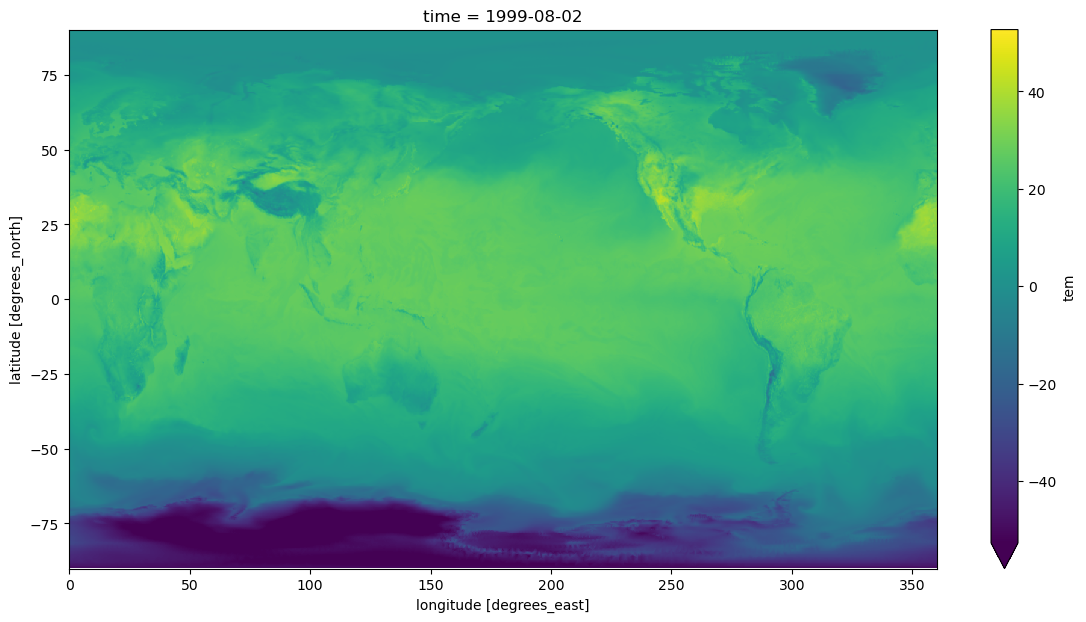

In [19]:
t2m.plot(x='longitude', y='latitude', cmap='viridis', size=7, aspect=2, add_colorbar=True, robust=True)

## Plot the data on a map

In [20]:
nx,ny = np.meshgrid(longitude,latitude,indexing='ij')

timeStr = '1999-08-02T00:00'

tl1 = f'ERA-5 t2m (degC)'
tl2 = f'Valid at: {timeStr}'
title_line = (tl1 + '\n' + tl2 + '\n') # concatenate the two strings and add return characters

In [21]:
cint = np.arange(-60,60,10)

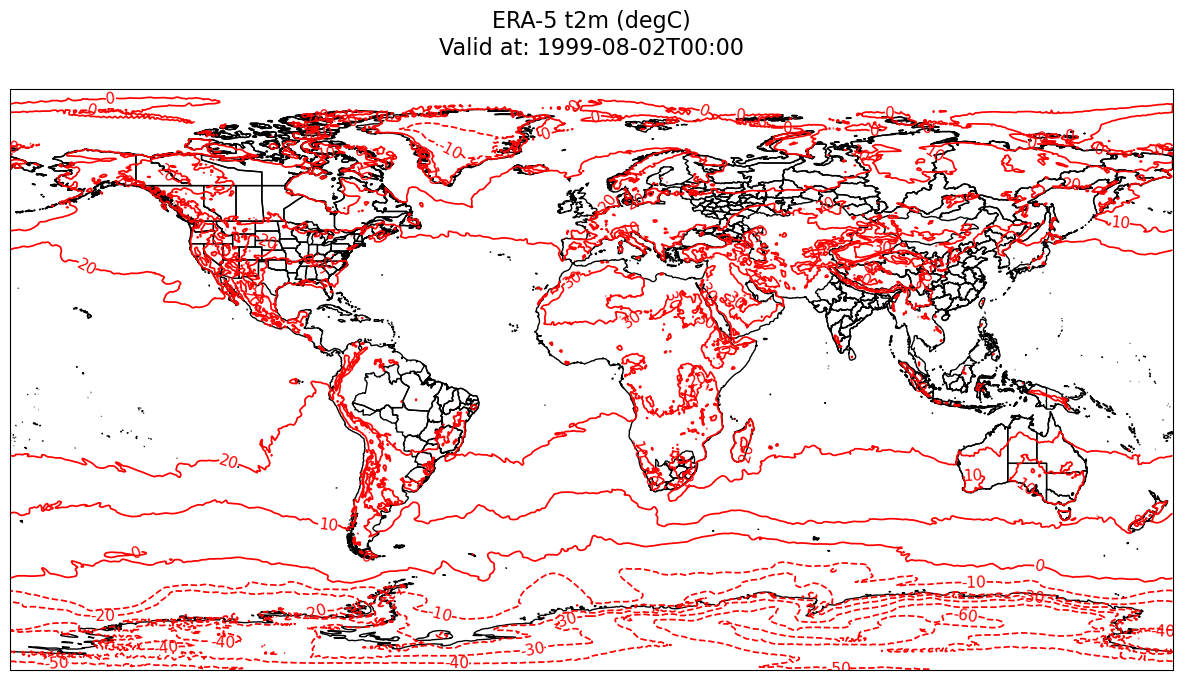

In [24]:
res = '50m'
fig = plt.figure(figsize=(15,10))
ax = plt.subplot(1,1,1,projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE.with_scale(res))
ax.add_feature(cfeature.STATES.with_scale(res))
#CL = slp.cf.plot.contour(levels=cint,linewidths=1.25,colors='green')
CL = ax.contour(nx, ny, t2m, transform=ccrs.PlateCarree(),levels=cint, linewidths=1.25, colors='red')
ax.clabel(CL, inline_spacing=0.2, fontsize=11, fmt='%.0f')

title = plt.title(title_line,fontsize=16)

figName = f'thumbnail.png'
fig.savefig(figName, dpi=100)

---

## Summary
In this notebook, we have accessed one of the ARCO ERA-5 datasets, regridded from the ECMWF native spectral to cartesian lat-lon coordinates, and created a map of 2-meter temperature for a particular date and time.